[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter20_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 20 (special chapter): Path Signatures and Realised Volatility

- The method of Gu, Guo, Jacobs, Kaminsky & Li (2024, ACM SIGKDD Conference on Knowledge Discovery and Data Mining, KDD) — signatures of the time-augmented path, two-step LASSO (least absolute shrinkage and selection operator), signature-kernel weights — transferred to forecasting daily realised variance on VOLARE.
- Target: five-minute realised variance (RV) averaged over the next $h$ days.
- Benchmarks: HAR (heterogeneous autoregressive model), log-HAR (HAR for log RV), HARQ (HAR with realised quarticity), SHAR (semivariance HAR); loss QLIKE (quasi-likelihood loss).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_20'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
# On Colab, install arch first: !pip install arch
# Colab: !pip install arch
import os
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import lars_path
import warnings
warnings.filterwarnings('ignore')

## VOLARE data

- VOLARE (Cipollini, Cruciani, Gallo, Insana, Otranto & Spagnolo, 2026, https://doi.org/10.48550/arXiv.2602.19732) is free for research at http://volare.unime.it.
- Download `realized_variance_stocks.csv`, `realized_variance_futures.csv` and `realized_variance_forex.csv` and set `VOLARE_DIR` to their folder.

In [2]:
# VOLARE is licensed for research use and is not redistributed with this course.
# Download the three realised-variance files free from http://volare.unime.it
# (realized_variance_stocks.csv, realized_variance_futures.csv, realized_variance_forex.csv)
# and set the folder that contains them (on Colab: upload them or mount Google Drive).
VOLARE_DIR = 'data/volare'
for _d in ('.', '..', '../..', '../../..'):
    if not os.path.isdir(VOLARE_DIR) and os.path.isdir(os.path.join(_d, 'data', 'volare')):
        VOLARE_DIR = os.path.join(_d, 'data', 'volare')
print('VOLARE folder:', os.path.abspath(VOLARE_DIR))

VOLARE folder: /Users/danpele/Documents/2026 MFM/MFM/data/volare


## Signatures, models and tests

- Truncated signatures by Chen's identity, the signature kernel, two-step LASSO with the Bayesian information criterion (BIC), HAR benchmarks, QLIKE, the Diebold-Mariano (DM) and Giacomini-White (GW) tests, the model confidence set (MCS).

In [3]:
CLASSES = ('stocks', 'futures', 'forex')
COLS = ['date', 'symbol', 'open_price', 'close_price', 'rv5', 'rsp5', 'rsn5', 'rq5', 'rk']
_RAW = {}


def load_class(kind):
    """All realised measures of one VOLARE asset class (stocks, futures, forex)."""
    if kind not in _RAW:
        f = os.path.join(VOLARE_DIR, f'realized_variance_{kind}.csv')
        _RAW[kind] = pd.read_csv(f, usecols=COLS, parse_dates=['date'])
    return _RAW[kind]


def load_asset(kind, symbol):
    """Daily series of one asset: rv (5-minute RV), semivariances, quarticity, kernel, open-to-close return."""
    d = load_class(kind)
    d = d[d.symbol == symbol].sort_values('date').set_index('date')
    out = pd.DataFrame({'rv': d.rv5, 'rsp': d.rsp5, 'rsn': d.rsn5, 'rq': d.rq5, 'rk': d.rk,
                        'r': np.log(d.close_price / d.open_price)})
    out = out[(out.rv > 0) & (out.rsp >= 0) & (out.rsn >= 0) & (out.rq > 0) & np.isfinite(out.r)]
    return out[~out.index.duplicated()]


def symbols(kind):
    return sorted(load_class(kind).symbol.unique())


# -----------------------------------------------------------------------------
# SIGNATURES (numpy, Chen's identity)
# -----------------------------------------------------------------------------
def sig_words(d, depth):
    """Multi-indices (words) of the truncated signature, levels 1..depth, in the order of sig_windows."""
    return [w for k in range(1, depth + 1) for w in itertools.product(range(d), repeat=k)]


def sig_path(path, depth=3):
    """Truncated signature (levels 1..depth) of the piecewise-linear path through the rows of `path` (m x d)."""
    return sig_windows(np.asarray(path, float), len(path), depth)[-1]


def _outer(A, B):
    """Row-wise tensor product of flattened tensors: (m, d^a) x (m, d^b) -> (m, d^(a+b)), lexicographic order."""
    return (A[:, :, None] * B[:, None, :]).reshape(A.shape[0], -1)


def sig_windows(x, l, depth=3):
    """Signatures of all rolling windows of l points of the path x (n x d); row i = window ending at point i.

    Chen's identity: S(X * Y) = S(X) (x) S(Y); a linear segment with increment D has S = exp(D) =
    (1, D, D(x)D/2!, D(x)D(x)D/3!, ...), so level k of the updated signature is
    sum_{p=0..k} S_old^(k-p) (x) D^(x)p / p!.  Rows i < l-1 are NaN."""
    x = np.asarray(x, float)
    n, d = x.shape
    m = n - l + 1
    lev = [np.ones((m, 1))] + [np.zeros((m, d ** k)) for k in range(1, depth + 1)]
    for j in range(l - 1):
        D = x[j + 1:j + 1 + m] - x[j:j + m]                        # increment of segment j in every window
        pw = [np.ones((m, 1))]
        for p in range(1, depth + 1):
            pw.append(_outer(pw[-1], D) / p)                       # D^(x)p / p!
        lev = [lev[0]] + [sum(_outer(lev[k - p], pw[p]) for p in range(0, k + 1)) for k in range(1, depth + 1)]
    flat = np.concatenate(lev[1:], axis=1)
    out = np.full((n, flat.shape[1]), np.nan)
    out[l - 1:] = flat
    return out


def sig_scale(scales, depth=3):
    """Signature of a path whose channel c is multiplied by scales[c]: level-k word (i1..ik) scales by prod."""
    return np.array([np.prod([scales[i] for i in w]) for w in sig_words(len(scales), depth)])


def levy_area(path):
    """Levy area of the first two channels: (S^(1,2) - S^(2,1)) / 2."""
    S = sig_path(path, 2)
    d = np.asarray(path).shape[1]
    s2 = S[d:].reshape(d, d)
    return 0.5 * (s2[0, 1] - s2[1, 0])


def sig_kernel(Sa, Sb):
    """Truncated signature kernel <S^N(a), S^N(b)> including the level-0 term 1."""
    return 1.0 + np.dot(Sa, Sb)


def sig_distance(Sa, Sb):
    """d_Sig(a, b) = k(a,a) - 2 k(a,b) + k(b,b) = ||S^N(a) - S^N(b)||^2."""
    return sig_kernel(Sa, Sa) - 2 * sig_kernel(Sa, Sb) + sig_kernel(Sb, Sb)


# -----------------------------------------------------------------------------
# DESIGN (pre-registered, fixed before any out-of-sample result)
# -----------------------------------------------------------------------------
CFG = dict(
    W=1000,             # rolling estimation window (days of (x_tau, y_tau+h) pairs)
    K=5,                # re-estimation every K trading days (parameters fixed in between)
    L=22,               # signature lookback (points in the path), one trading month
    DEPTH=3,            # truncation depth N
    HORIZONS=(1, 5, 22),
    VAL=250,            # validation block: first 250 forecast days of every asset (only for choosing c)
    C_GRID=(0.5, 1.0, 2.0, 4.0),   # gamma = c / median(d_tau)
    CHANNELS=('t', 'logrv', 'cumret'),
)
MODELS = ['HAR', 'logHAR', 'HARQ', 'SHAR', 'logHAR-K', 'Sig-L', 'Sig-LK']
LABEL = {'HAR': 'HAR', 'logHAR': 'log-HAR', 'HARQ': 'HARQ', 'SHAR': 'SHAR', 'logHAR-K': 'log-HAR + kernel weights',
         'Sig-L': 'Signature LASSO', 'Sig-LK': 'Signature LASSO + kernel weights'}


def har_parts(v):
    """Daily, weekly (5-day) and monthly (22-day) averages of a series ending at each day."""
    s = pd.Series(v)
    return np.c_[s.values, s.rolling(5).mean().values, s.rolling(22).mean().values]


def build_design(a, h, cfg=CFG):
    """Features and targets of one asset for horizon h (arrays aligned on the asset's trading days)."""
    rv = a.rv.values
    n = len(rv)
    lrv = np.log(rv)
    y = pd.Series(rv).rolling(h).mean().shift(-h).values       # mean RV over days t+1..t+h
    H = har_parts(rv)
    D = dict(dates=a.index, rv=rv, y=y, ly=np.log(y), n=n, h=h)
    D['X_har'] = H
    D['X_loghar'] = np.log(H)
    D['sqrq'] = np.sqrt(a.rq.values)
    D['X_shar'] = np.c_[a.rsp.values, a.rsn.values, H[:, 1], H[:, 2]]
    # path for the signature: (time, log RV, cumulative open-to-close return), channels as in cfg
    chan = {'t': np.arange(n, dtype=float) / (cfg['L'] - 1), 'logrv': lrv, 'cumret': np.cumsum(a.r.values),
            'rsn': np.log(np.maximum(a.rsn.values, 1e-12))}
    P = np.column_stack([chan[c] for c in cfg['CHANNELS']])
    D['path'] = P
    D['sig'] = sig_windows(P, cfg['L'], cfg['DEPTH'])
    D['incr'] = np.r_[np.full((1, P.shape[1]), np.nan), np.diff(P, axis=0)]
    return D


# -----------------------------------------------------------------------------
# ESTIMATION
# -----------------------------------------------------------------------------
def wls(X, y, w):
    """Weighted least squares with intercept; returns coefficients (b0, b) and weighted residual variance."""
    Z = np.c_[np.ones(len(y)), X]
    sw = np.sqrt(w)
    b, *_ = np.linalg.lstsq(Z * sw[:, None], y * sw, rcond=None)
    e = y - Z @ b
    return b, float(np.sum(w * e ** 2) / np.sum(w))


def two_step_lasso(X, y, w, max_steps=60):
    """Weighted LASSO path (LARS) -> OLS refit on each support -> BIC with Kish effective sample size.

    Step 1 (Gu et al., 2024, Eq. 14): min_theta sum_tau w_tau (y - x theta)^2 + lambda ||theta||_1.
    Step 2 (Eq. 15): weighted OLS on supp(theta_LASSO).  lambda chosen by BIC inside the window."""
    w = w / w.sum()
    n_eff = 1.0 / np.sum(w ** 2)
    mx = w @ X
    my = w @ y
    sd = np.sqrt(w @ (X - mx) ** 2)
    keep = sd > 1e-12
    Xs = (X[:, keep] - mx[keep]) / sd[keep]
    sw = np.sqrt(w)
    _, _, coefs = lars_path(Xs * sw[:, None], (y - my) * sw, method='lasso', max_iter=max_steps)
    idx = np.where(keep)[0]
    best, seen = None, set()
    for j in range(coefs.shape[1]):
        S = tuple(idx[np.abs(coefs[:, j]) > 0])
        if S in seen:
            continue
        seen.add(S)
        b, s2 = wls(X[:, list(S)], y, w) if S else (np.array([my]), float(w @ (y - my) ** 2))
        bic = n_eff * np.log(s2) + (len(S) + 1) * np.log(n_eff)
        if best is None or bic < best[0]:
            best = (bic, S, b, s2)
    _, S, b, s2 = best
    beta = np.zeros(X.shape[1])
    beta[list(S)] = b[1:]
    return b[0], beta, s2, S


def kernel_weights(sig_train, sig_now, scale, c):
    """w_tau proportional to exp(-gamma d_Sig(window tau, current window)), gamma = c / median(d)."""
    diff = (sig_train - sig_now) * scale
    d = np.sum(diff ** 2, axis=1)
    g = c / np.median(d)
    z = -g * d
    w = np.exp(z - z.max())
    return w / w.sum(), d


def insanity(fc, models):
    """Bollerslev, Patton & Quaedvlieg (2016) filter: a forecast outside the range of the target in the estimation
    window is replaced by the window mean (columns lo, hi, mu of a forecast table)."""
    out = fc.copy()
    for m in models:
        bad = (fc[m] < fc.lo) | (fc[m] > fc.hi)
        out.loc[bad, m] = fc.mu[bad]
    return out


def fit_models(D, t, cfg, c_sig, c_har, models=MODELS, keep_weights=False):
    """Estimate every model at origin t (information up to day t); return a dict of forecast functions."""
    h, W, L = D['h'], cfg['W'], cfg['L']
    tr = np.arange(t - h - W + 1, t - h + 1)                     # tau with tau + h <= t
    y, ly = D['y'][tr], D['ly'][tr]
    uni = np.full(len(tr), 1.0 / len(tr))
    out, info = {}, {}
    if 'HAR' in models:
        b, _ = wls(D['X_har'][tr], y, uni)
        out['HAR'] = ('lvl', b, None, 0.0)
    if 'logHAR' in models:
        b, s2 = wls(D['X_loghar'][tr], ly, uni)
        out['logHAR'] = ('log', b, None, s2)
    if 'HARQ' in models:
        mq = D['sqrq'][tr].mean()
        X = np.c_[D['X_har'][tr, 0], D['X_har'][tr, 0] * (D['sqrq'][tr] - mq), D['X_har'][tr, 1:]]
        b, _ = wls(X, y, uni)
        out['HARQ'] = ('harq', b, mq, 0.0)
    if 'SHAR' in models:
        b, _ = wls(D['X_shar'][tr], y, uni)
        out['SHAR'] = ('shar', b, None, 0.0)
    need_sig = any(m in models for m in ('Sig-L', 'Sig-LK', 'logHAR-K'))
    if need_sig:
        # channel scales from the training window: each non-time channel / (sd of daily increments * sqrt(L-1))
        inc = D['incr'][tr[0]:t + 1]
        sc = []
        for j, cname in enumerate(cfg['CHANNELS']):
            sc.append(1.0 if cname == 't' else 1.0 / (np.nanstd(inc[:, j]) * np.sqrt(L - 1)))
        scale = sig_scale(np.array(sc), cfg['DEPTH'])
        Str = D['sig'][tr]
        Xsig = np.c_[D['X_loghar'][tr], Str * scale]
        if 'Sig-L' in models:
            b0, beta, s2, sup = two_step_lasso(Xsig, ly, uni)
            out['Sig-L'] = ('sig', np.r_[b0, beta], scale, s2)
            info['k_Sig-L'] = len(sup)
            info['S_Sig-L'] = ' '.join(map(str, sup))
        wk, dist = kernel_weights(Str, D['sig'][t], scale, c_sig)
        if 'Sig-LK' in models:
            b0, beta, s2, sup = two_step_lasso(Xsig, ly, wk)
            out['Sig-LK'] = ('sig', np.r_[b0, beta], scale, s2)
            info['k_Sig-LK'] = len(sup)
            info['S_Sig-LK'] = ' '.join(map(str, sup))
            info['ess'] = 1.0 / np.sum(wk ** 2)
            top = D['rv'][tr] >= np.quantile(D['rv'][tr], 0.9)
            info['hv_share'] = float(wk[top].sum())             # weight on the 10% most volatile training days
            info['date'] = D['dates'][t]
            if keep_weights:
                info['weights'] = pd.Series(wk, index=D['dates'][tr])
        if 'logHAR-K' in models:
            wh = wk if c_har == c_sig else kernel_weights(Str, D['sig'][t], scale, c_har)[0]
            b, s2 = wls(D['X_loghar'][tr], ly, wh)
            out['logHAR-K'] = ('log', b, None, s2)
    return out, info, (y.min(), y.max(), y.mean())


def predict(D, s, spec):
    kind, b, extra, s2 = spec
    if kind == 'lvl':
        return b[0] + D['X_har'][s] @ b[1:]
    if kind == 'shar':
        return b[0] + D['X_shar'][s] @ b[1:]
    if kind == 'harq':
        Xh = D['X_har'][s]
        X = np.c_[Xh[:, 0], Xh[:, 0] * (D['sqrq'][s] - extra), Xh[:, 1:]]
        return b[0] + X @ b[1:]
    if kind == 'log':
        return np.exp(b[0] + D['X_loghar'][s] @ b[1:] + 0.5 * s2)
    if kind == 'sig':
        X = np.c_[D['X_loghar'][s], D['sig'][s] * extra]
        return np.exp(b[0] + X @ b[1:] + 0.5 * s2)
    raise ValueError(kind)


def first_origin(D, cfg):
    """First forecast origin: HAR needs 22 days, the signature L points, the training window W pairs."""
    return max(22, cfg['L']) + cfg['W'] + D['h']


def eval_start(D, cfg, cutoff=None):
    """First evaluation origin: after the asset's validation block + h days and, if given, strictly after the date of
    the last validation target of its asset class (cutoff), so that no evaluated origin precedes a tuning target."""
    st = first_origin(D, cfg) + cfg['VAL'] + D['h']
    if cutoff is not None:
        st = max(st, int(D['dates'].searchsorted(pd.Timestamp(cutoff), side='right')))
    return st


def tuned(res, kind, h):
    """(c for Sig-LK, c for log-HAR-K, class cutoff date) chosen on the validation block of the asset class
    (from ch20_results.json: keys 'validation' and 'val_cutoff')."""
    v = res['validation']
    return v[f'{kind}|Sig-LK|{h}']['c'], v[f'{kind}|logHAR-K|{h}']['c'], res['val_cutoff'][f'{kind}|{h}']


def run_forecasts(D, cfg, c_sig, c_har, start, stop, models=MODELS, weight_dates=()):
    """Rolling forecasts for origins start..stop-1; re-estimation every cfg['K'] days.
    For a date in weight_dates the kernel weights are recomputed at that exact origin (diagnostic; the forecast of that
    day still uses the coefficients estimated at the start of its 5-day block)."""
    rows, ks, wsave = [], [], {}
    wd = set(pd.DatetimeIndex(weight_dates))
    t = start
    while t < stop:
        blk = np.arange(t, min(t + cfg['K'], stop))
        specs, info, (lo, hi, mu) = fit_models(D, t, cfg, c_sig, c_har, models)
        for s in blk:
            if D['dates'][s] in wd:
                _, inf_s, _ = fit_models(D, s, cfg, c_sig, c_har, ['Sig-LK'], keep_weights=True)
                wsave[D['dates'][s]] = inf_s.get('weights')
        f = {m: predict(D, blk, specs[m]) for m in models}
        for m in models:                                          # positivity: QLIKE needs f > 0
            v = f[m]
            f[m] = np.where((v <= 0) | ~np.isfinite(v), mu, v)
        for i, s in enumerate(blk):
            rows.append([D['dates'][s], D['y'][s], lo, hi, mu] + [f[m][i] for m in models])
        ks.append({k: v for k, v in info.items() if k != 'weights'})
        t += cfg['K']
    fc = pd.DataFrame(rows, columns=['date', 'y', 'lo', 'hi', 'mu'] + list(models)).set_index('date')
    return fc, pd.DataFrame(ks), wsave


# -----------------------------------------------------------------------------
# EVALUATION
# -----------------------------------------------------------------------------
def qlike(y, f):
    """QLIKE(y, f) = y/f - log(y/f) - 1 (Patton, 2011): y is the realised proxy, f the forecast."""
    r = y / f
    return r - np.log(r) - 1.0


def mse(y, f):
    return (y - f) ** 2


def nw_var(d, lag):
    """Newey-West (Bartlett) long-run variance of a series."""
    d = np.asarray(d, float) - np.mean(d)
    T = len(d)
    v = d @ d / T
    for j in range(1, lag + 1):
        v += 2 * (1 - j / (lag + 1)) * (d[j:] @ d[:-j]) / T
    return v


def nw_lag(T, h):
    return int(max(h, np.ceil(T ** (1 / 3))))


def dm_test(la, lb, h):
    """Diebold-Mariano: d = L_A - L_B; t = mean(d) / sqrt(NW var / T); one-sided p for 'A beats B' (d < 0)."""
    d = np.asarray(la) - np.asarray(lb)
    T = len(d)
    t = d.mean() / np.sqrt(nw_var(d, nw_lag(T, h)) / T)
    return t, stats.norm.cdf(t), 2 * stats.norm.sf(abs(t))


def gw_test(la, lb, h):
    """Giacomini-White conditional test, instruments (1, d_{t-h}); Wald ~ chi2(2)."""
    d = np.asarray(la) - np.asarray(lb)
    Z = np.c_[np.ones(len(d) - h), d[:-h]] * d[h:, None]
    T = len(Z)
    zb = Z.mean(0)
    Zc = Z - zb
    lag = nw_lag(T, h)
    O = Zc.T @ Zc / T
    for j in range(1, lag + 1):
        G = Zc[j:].T @ Zc[:-j] / T
        O += (1 - j / (lag + 1)) * (G + G.T)
    stat = T * zb @ np.linalg.solve(O, zb)
    return stat, stats.chi2.sf(stat, 2)


def holm(p):
    p = np.asarray(p)
    o = np.argsort(p)
    m = len(p)
    adj = np.maximum.accumulate((m - np.arange(m)) * p[o])
    out = np.empty(m)
    out[o] = np.minimum(adj, 1)
    return out


def bh(p):
    p = np.asarray(p)
    o = np.argsort(p)
    m = len(p)
    adj = np.minimum.accumulate((m / np.arange(m, 0, -1)) * p[o][::-1])[::-1]
    out = np.empty(m)
    out[o] = np.minimum(adj, 1)
    return out


def mcs(losses, size=0.10, reps=1000, block=None, seed=20):
    """Model confidence set (Hansen, Lunde & Nason, 2011), T_max statistic, stationary bootstrap."""
    from arch.bootstrap import MCS
    L = pd.DataFrame(losses)
    m = MCS(L, size=size, reps=reps, block_size=block or 10, method='max', bootstrap='stationary', seed=seed)
    m.compute()
    return list(m.included), m.pvalues['Pvalue'].to_dict()

## Chart style

In [4]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'
COL = {'HAR': MainBlue, 'logHAR': Teal, 'HARQ': Purple, 'SHAR': Amber, 'logHAR-K': Orange,
       'Sig-L': Forest, 'Sig-LK': IDAred}
SHORT = {'HAR': 'HAR', 'logHAR': 'log-HAR', 'HARQ': 'HARQ', 'SHAR': 'SHAR', 'logHAR-K': 'log-HAR-K',
         'Sig-L': 'Sig-L', 'Sig-LK': 'Sig-LK'}
CLASS_LABEL = {'stocks': 'US stocks (40)', 'futures': 'Futures (5)', 'forex': 'FX (5)', 'all': 'All 50 assets'}
PERIODS = {'covid': ('2020-02-20', '2020-04-30'), 'apr2025': ('2025-04-02', '2025-04-30')}
H = CFG['HORIZONS']


def save_fig(name):
    """Show the figure (the Quantlet folder contains the saved PDF/PNG)."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, axes, ncol=4, y=0.0):
    """One legend below a figure with several panels."""
    h, l = [], []
    for ax in axes:
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l:
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)

## 1. Signatures step by step

- Chen's identity, the Lévy area and the two-segment example of the lecture.

In [5]:
# Chen's identity and the Levy area, numerically
rng = np.random.default_rng(0)
P = rng.normal(size=(7, 3)).cumsum(0)
A, B, AB = sig_path(P[:4], 3), sig_path(P[3:], 3), sig_path(P, 3)
split = lambda s: [np.array([1.0]), s[:3], s[3:12], s[12:]]
a, b = split(A), split(B)
chen = np.concatenate([sum(np.outer(a[k - p], b[p]).ravel() for p in range(k + 1)) for k in range(1, 4)])
print('Chen identity holds:', np.allclose(chen, AB))
print('Levy area of the unit square (anticlockwise):', levy_area(np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], float)))
print('Two-segment example (0,0)->(1,0)->(1,2): level 2 =', sig_path(np.array([[0, 0], [1, 0], [1, 2]], float), 2)[2:].reshape(2, 2).tolist())

Chen identity holds: True
Levy area of the unit square (anticlockwise): 1.0
Two-segment example (0,0)->(1,0)->(1,2): level 2 = [[0.5, 2.0], [0.0, 2.0]]


## 2. Two windows of JPM as paths

- Path (cumulative open-to-close return, log RV) over 22 days: a calm window and the COVID-19 crash.

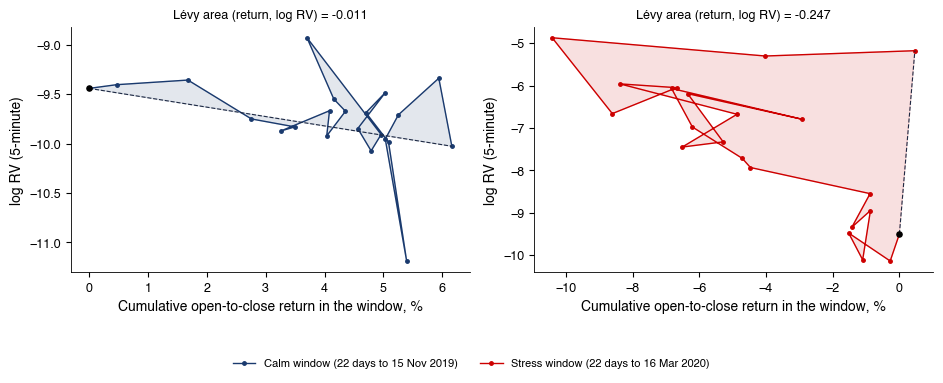

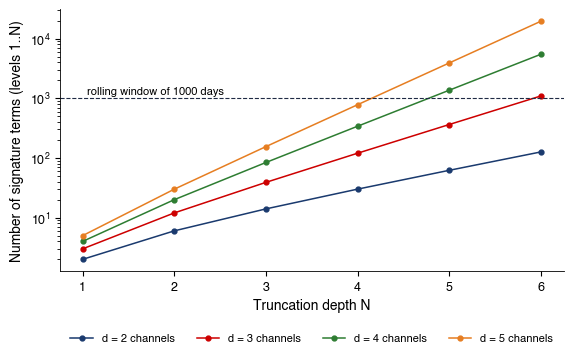

{'2019-11-15': {'levy': -0.010687183596720377,
  'dlogrv': -0.5848986623416774,
  'dret': 6.164728457545678,
  'sig_lvl1': [1.0, -0.5848986623416774, 0.06164728457545678]},
 '2020-03-16': {'levy': -0.24743820318288412,
  'dlogrv': 4.322415470734051,
  'dret': 0.464226830633896,
  'sig_lvl1': [1.0, 4.322415470734051, 0.004642268306338959]}}

In [6]:
RES = {}


def chart_signature_demo():
    """Lead-lag of (log RV, cumulative return) for JPM in the 22 days before 16 March 2020 and in a calm window."""
    a = load_asset('stocks', 'JPM')
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
    out = {}
    for ax, end, lab, c in [(axes[0], '2019-11-15', 'Calm window (22 days to 15 Nov 2019)', MainBlue),
                            (axes[1], '2020-03-16', 'Stress window (22 days to 16 Mar 2020)', IDAred)]:
        j = a.index.searchsorted(pd.Timestamp(end))
        w = a.iloc[j - 21:j + 1]
        x = np.cumsum(w.r.values) * 100
        x = x - x[0]
        yv = np.log(w.rv.values)
        ax.plot(x, yv, '-o', color=c, ms=2.5, lw=1.0, label=lab)
        ax.fill(np.r_[x, x[0]], np.r_[yv, yv[0]], color=c, alpha=0.12)
        ax.plot([x[0], x[-1]], [yv[0], yv[-1]], color=Gray, lw=0.8, ls='--')
        ax.scatter([x[0]], [yv[0]], color='black', zorder=5, s=14)
        ax.set_xlabel('Cumulative open-to-close return in the window, %')
        ax.set_ylabel('log RV (5-minute)')
        P = np.c_[np.linspace(0, 1, 22), yv, x / 100]
        sg = sig_path(P, 2)
        la = levy_area(np.c_[x / 100, yv])
        ax.set_title(f'Lévy area (return, log RV) = {la:+.3f}', fontsize=9)
        out[end] = {'levy': float(la), 'dlogrv': float(yv[-1] - yv[0]), 'dret': float(x[-1]),
                    'sig_lvl1': sg[:3].tolist()}
    fig_legend_bottom(fig, axes, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch20_signature_demo')
    RES['sig_demo'] = out


def chart_sig_dimension():
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    Ns = np.arange(1, 7)
    for d, c in [(2, MainBlue), (3, IDAred), (4, Forest), (5, Orange)]:
        M = [(d ** (n + 1) - 1) // (d - 1) - 1 for n in Ns]
        ax.plot(Ns, M, '-o', color=c, ms=3.5, label=f'd = {d} channels')
    ax.set_yscale('log')
    ax.axhline(1000, color=Gray, ls='--', lw=0.8)
    ax.text(1.05, 1150, 'rolling window of 1000 days', fontsize=8, color='black')
    ax.set_xlabel('Truncation depth N')
    ax.set_ylabel('Number of signature terms (levels 1..N)')
    legend_outside_bottom(ax, ncol=4, y=-0.2)
    save_fig('ch20_sig_dimension')


def assets():
    return [(k, s) for k in CLASSES for s in symbols(k)]

chart_signature_demo()
chart_sig_dimension()
RES['sig_demo']

## 3. Rolling forecasts: signature LASSO vs the HAR family

- Pre-registered design: window of 1000 days, re-estimation every 5 days, path (time, log RV, cumulative return), depth 3.
- Here two assets at the one-day horizon; the lecture runs 50 assets and three horizons.

In [7]:
RES_LECTURE = None
for _d in ('.', '../../Quantlets/Ch_20', '../Quantlets/Ch_20'):
    if os.path.exists(os.path.join(_d, 'ch20_results.json')):
        RES_LECTURE = json.load(open(os.path.join(_d, 'ch20_results.json')))
FALLBACK = {'validation': {f'{k}|{m}|{hh}': {'c': 0.5} for k in CLASSES for m in ('Sig-LK', 'logHAR-K') for hh in (1, 5, 22)},
            'val_cutoff': {f'{k}|{hh}': None for k in CLASSES for hh in (1, 5, 22)}}
H = 1                                   # forecast horizon in days: 1, 5 or 22
ASSETS = [('stocks', 'JPM'), ('futures', 'ES')]
rows, FC = [], {}
for kind, sym in ASSETS:
    a = load_asset(kind, sym)
    D = build_design(a, H)
    # c chosen on the validation block of the asset class; evaluation starts after the class cutoff date
    c_sig, c_har, cutoff = tuned(RES_LECTURE or FALLBACK, kind, H)
    st = eval_start(D, CFG, cutoff)
    fc, info, ws = run_forecasts(D, CFG, c_sig, c_har, st, len(a) - H,
                                 weight_dates=[pd.Timestamp('2020-03-16')] if sym == 'JPM' else ())
    FC[sym] = (fc, ws)
    q = {m: qlike(fc.y.values, fc[m].values) for m in MODELS}
    inc, _ = mcs(pd.DataFrame(q), block=max(H, 10))
    for m in MODELS:
        t, p1, _ = dm_test(q[m], q['logHAR'], H) if m != 'logHAR' else (np.nan, np.nan, np.nan)
        rows.append({'asset': sym, 'model': m, 'QLIKE / log-HAR': q[m].mean() / q['logHAR'].mean(),
                     'DM t vs log-HAR': t, 'one-sided p': p1, 'in 90% MCS': m in inc})
pd.DataFrame(rows).round(3)

,asset,model,QLIKE / log-HAR,DM t vs log-HAR,one-sided p,in 90% MCS
0,JPM,HAR,1.076,1.033,0.849,True
1,JPM,logHAR,1.000,NaN,NaN,True
2,JPM,HARQ,1.177,2.213,0.987,False
3,JPM,SHAR,1.155,1.750,0.960,False
4,JPM,logHAR-K,0.993,-1.349,0.089,True
5,JPM,Sig-L,1.003,0.163,0.565,True
6,JPM,Sig-LK,1.000,-0.017,0.493,True
7,ES,HAR,1.168,2.912,0.998,True
8,ES,logHAR,1.000,NaN,NaN,True
9,ES,HARQ,1.656,1.385,0.917,True


## 4. What do the kernel weights pick in a crash?

- Weights of Sig-LK for JPM computed at the origin 16 March 2020 (h = 1), relative to equal weighting.

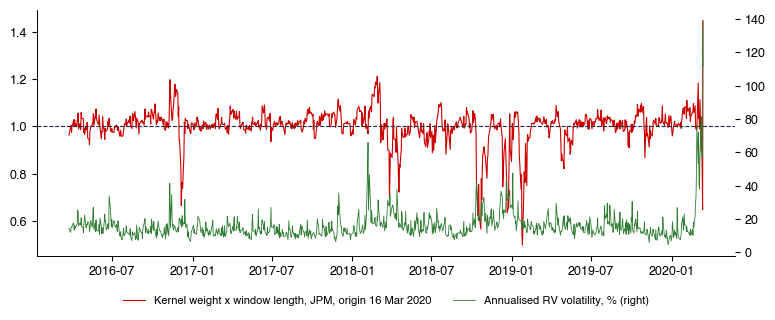

effective sample size: 994 of 1000


In [8]:
fc, ws = FC['JPM']   # run section 3 with H = 1
w = list(ws.values())[0]
a = load_asset('stocks', 'JPM')
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(w.index, w * len(w), color=IDAred, lw=0.8, label='Kernel weight x window length, JPM, origin 16 Mar 2020')
ax.axhline(1, color=Gray, ls='--', lw=0.8)
ax2 = ax.twinx()
ax2.plot(w.index, 100 * np.sqrt(252 * a.rv.reindex(w.index)), color=Forest, lw=0.6, label='Annualised RV volatility, % (right)')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.show()
print('effective sample size:', round(1 / np.sum(w.values ** 2)), 'of', len(w))

## Your turn

- Replace `('futures', 'ES')` by another asset (for example `('forex', 'EURUSD')`) and set `H = 5` in section 3 (the design, the evaluation window, the DM bandwidth and the tuned $c$ all follow `H`).
- Does the ranking of log-HAR and Sig-LK change? Set `CFG['DEPTH'] = 2` and compare.